In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import kagglehub
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

2026-05-29 23:33:36.070240: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-29 23:33:36.341888: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-29 23:33:37.559565: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-29 23:33:40.869290: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# ============================================================
# 2. DOWNLOAD DATASET
# ============================================================

path = kagglehub.dataset_download("feyzazkefe/trashnet")
dataset_dir = os.path.join(path, "dataset-resized")

print("Dataset path:", dataset_dir)
print("Classes:", os.listdir(dataset_dir))

Dataset path: /home/norah/.cache/kagglehub/datasets/feyzazkefe/trashnet/versions/1/dataset-resized
Classes: ['glass', 'metal', 'cardboard', 'paper', 'plastic', 'trash']


In [3]:
# ============================================================
# 3. DATASET INFORMATION
# ============================================================

class_counts = {}
total_images = 0
image_sizes = {}

for cls in os.listdir(dataset_dir):
    cls_path = os.path.join(dataset_dir, cls)

    if os.path.isdir(cls_path):
        files = os.listdir(cls_path)
        class_counts[cls] = len(files)
        total_images += len(files)

        for img_name in files:
            img_path = os.path.join(cls_path, img_name)

            try:
                img = Image.open(img_path)
                size = img.size
                image_sizes[size] = image_sizes.get(size, 0) + 1
            except:
                pass

print("Images per class:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

print("\nTotal images:", total_images)
print("Number of unique image sizes:", len(image_sizes))

print("\nImage sizes:")
for size, count in image_sizes.items():
    print(f"{size}: {count} images")

Images per class:
glass: 501
metal: 410
cardboard: 403
paper: 594
plastic: 482
trash: 137

Total images: 2527
Number of unique image sizes: 1

Image sizes:
(512, 384): 2527 images


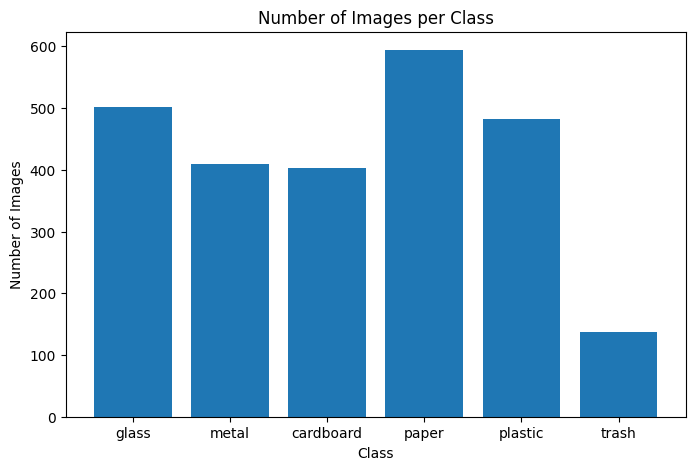

In [4]:
# ============================================================
# 4. CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

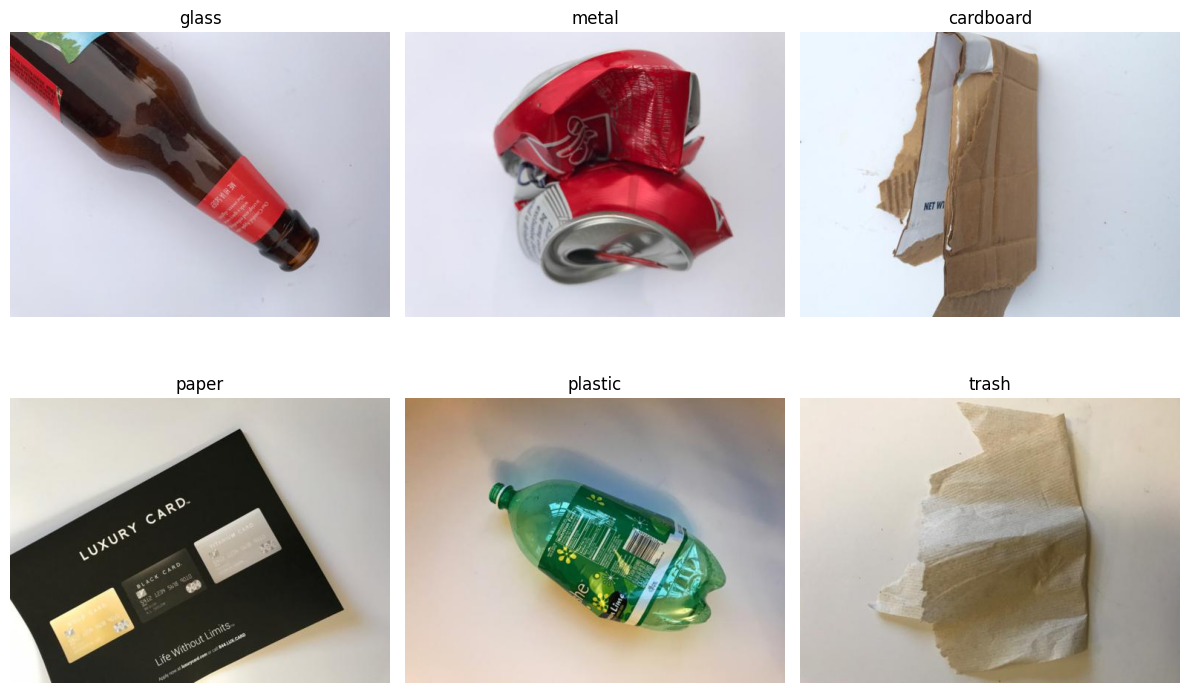

In [5]:
# ============================================================
# 5. VISUALIZE SAMPLE IMAGES
# ============================================================

classes = list(class_counts.keys())

plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):
    cls_path = os.path.join(dataset_dir, cls)
    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# 6. DATA GENERATORS
# Experiment 1: Original Images
# Experiment 2: Image Processing / Augmentation
# ============================================================

img_size = (224, 224)
batch_size = 32

# Original images: only MobileNet preprocessing
original_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

# Processed images: preprocessing + image augmentation
processed_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,

    # Image processing / augmentation techniques
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

In [7]:
# ============================================================
# 7. ORIGINAL IMAGE DATA
# ============================================================

original_train = original_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

original_val = original_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print("Class indices:", original_train.class_indices)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Class indices: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [8]:
# ============================================================
# 8. PROCESSED / AUGMENTED IMAGE DATA
# Validation is kept original for fair comparison
# ============================================================

processed_train = processed_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

processed_val = original_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


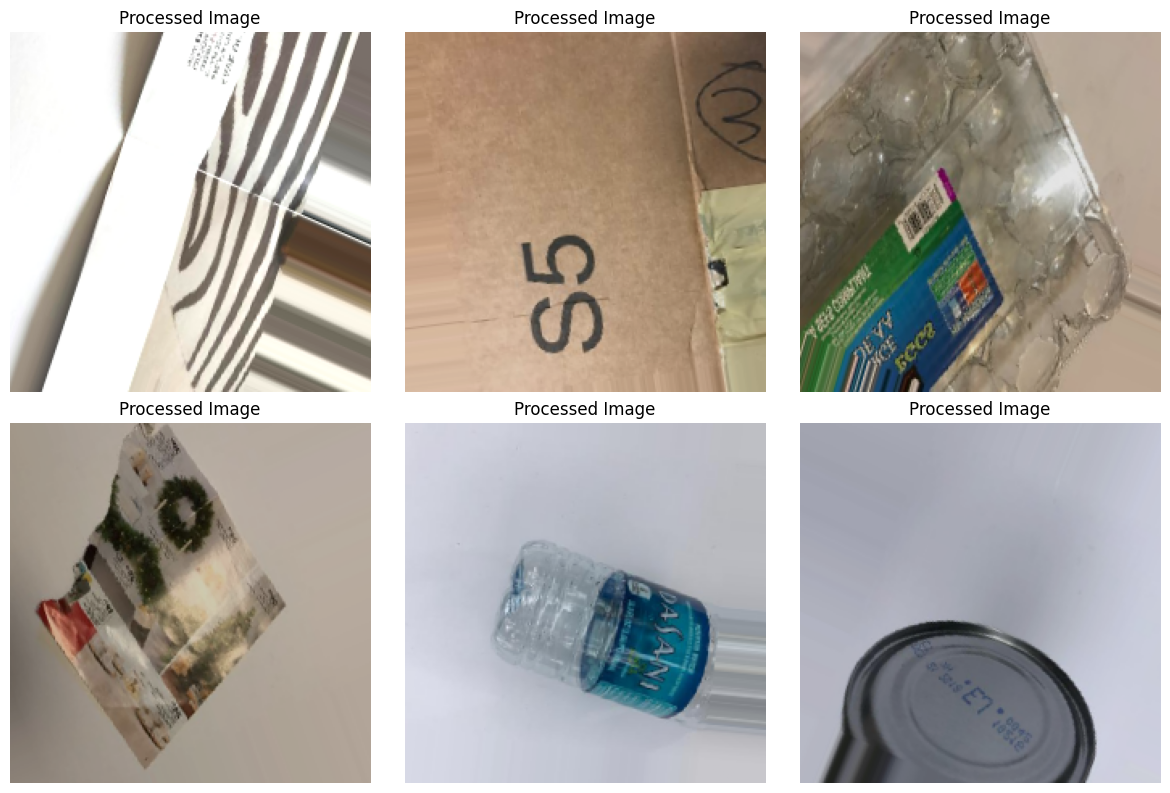

In [9]:
# ============================================================
# 9. VISUALIZE AUGMENTED IMAGES
# ============================================================

x_batch, y_batch = next(processed_train)

plt.figure(figsize=(12, 8))

for i in range(6):
    img = x_batch[i]

    # Convert image back from MobileNetV2 preprocessing for display
    img_display = (img + 1) / 2
    img_display = np.clip(img_display, 0, 1)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img_display)
    plt.title("Processed Image")
    plt.axis("off")

plt.tight_layout()
plt.show()